# Notebook 4 — Exploratory Data Analysis

## Objective

This notebook performs detailed exploratory data analysis on the training split only.

The analysis focuses on:

- Understanding the structure and data types of the training data
- Examining missing values
- Exploring numerical and categorical variables
- Identifying distributions, skewness, and potential outliers
- Analyzing relationships between features and delivery delays
- Investigating time-based patterns
- Investigating geographic patterns
- Identifying potential features for the next stage

Only the training split is used in this notebook to avoid data leakage.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [123]:
from pathlib import Path

artifact_dir = Path("../Artifacts/N4_eda/charts")
artifact_dir.mkdir(parents=True, exist_ok=True)

In [61]:
train = pd.read_csv("../Artifacts/train.csv")

## 1. Data Overview

The training split is used as the only dataset for this exploratory analysis.

This section examines the shape, structure, data types, and role of the variables before performing detailed analysis.

In [62]:
train.shape

(67533, 14)

In [63]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       67533 non-null  str    
 1   customer_id                    67533 non-null  str    
 2   order_status                   67533 non-null  str    
 3   order_purchase_timestamp       67533 non-null  str    
 4   order_approved_at              67519 non-null  str    
 5   order_delivered_carrier_date   67532 non-null  str    
 6   order_delivered_customer_date  67533 non-null  str    
 7   order_estimated_delivery_date  67533 non-null  str    
 8   number_of_items                67533 non-null  float64
 9   total_price                    67533 non-null  float64
 10  total_freight                  67533 non-null  float64
 11  number_of_payments             67532 non-null  float64
 12  total_payment_value            67532 non-null  float64
 1

In [64]:
train.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
number_of_items                  float64
total_price                      float64
total_freight                    float64
number_of_payments               float64
total_payment_value              float64
delivery_label                       str
dtype: object

### Column Types and Roles

The training dataset contains identifiers, numerical variables, categorical variables, and date/time variables.

- **Identifiers:** `order_id`, `customer_id`
- **Categorical:** `order_status`, `delivery_label`
- **Numerical:** `number_of_items`, `total_price`, `total_freight`, `number_of_payments`, `total_payment_value`
- **Date/Time:** `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`

## 2. Missing Values

Missing values were examined to identify variables with incomplete information and determine whether the missingness could carry useful information.

In [65]:
missing_summary = (
    train.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(train) * 100
)

missing_summary.sort_values(
    "missing_pct",
    ascending=False
)

,missing_count,missing_pct
order_approved_at,14,0.020731
order_delivered_carrier_date,1,0.001481
number_of_payments,1,0.001481
total_payment_value,1,0.001481
customer_id,0,0.000000
order_id,0,0.000000
order_status,0,0.000000
order_purchase_timestamp,0,0.000000
order_delivered_customer_date,0,0.000000
order_estimated_delivery_date,0,0.000000


### Findings

Missing values are very limited in the training split.

- `order_approved_at` has 14 missing values (0.02%).
- `order_delivered_carrier_date` has 1 missing value (0.001%).
- `number_of_payments` has 1 missing value (0.001%).
- `total_payment_value` has 1 missing value (0.001%).

The missing values represent a negligible portion of the training data. However, the missingness in delivery-related dates should be considered carefully because it may reflect an incomplete delivery process rather than random missingness.

Missing values will be handled during feature engineering in Notebook 5.

## 3. Target Variable

The target variable is `delivery_label`, which indicates whether an order was delivered late or on time.

In [66]:
train["delivery_label"].value_counts()

delivery_label
on_time    62242
late        5291
Name: count, dtype: int64

In [67]:
train["delivery_label"].value_counts(normalize=True) * 100

delivery_label
on_time    92.165312
late        7.834688
Name: proportion, dtype: float64

### Finding

The target is imbalanced. Late deliveries represent approximately 7.84% of the training orders, while on-time deliveries represent approximately 92.16%.

Therefore, accuracy alone should not be used as the primary evaluation metric during model evaluation.

## 4. Numerical Features

Numerical variables were examined using descriptive statistics to understand their ranges, central tendency, variability, and potential outliers.

In [68]:
numeric_cols = [
    "number_of_items",
    "total_price",
    "total_freight",
    "number_of_payments",
    "total_payment_value"
]

train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_items,67533.0,1.142079,0.541635,1.00,1.00,1.00,1.000,21.00
total_price,67533.0,135.884499,205.187627,2.29,45.90,85.00,149.900,13440.00
total_freight,67533.0,22.244256,19.999582,0.00,14.10,16.79,23.700,1002.29
number_of_payments,67532.0,1.047622,0.397212,1.00,1.00,1.00,1.000,26.00
total_payment_value,67532.0,158.167657,214.277783,10.07,61.63,104.19,175.485,13664.08


### Findings

The numerical features are generally right-skewed, with several variables containing high-value observations.

- `number_of_items` is concentrated at one item per order, with a maximum of 21 items.
- `total_price` and `total_payment_value` show strong right-skewness, with maximum values substantially above their medians.
- `total_freight` also contains high-value observations compared with its typical range.
- `number_of_payments` is highly concentrated at one payment per order, with a small number of orders having substantially more payments.

These extreme values should be reviewed during feature engineering. They should not automatically be removed because they may represent legitimate high-value or multi-item orders.

### Numerical Feature Distributions

Histograms are used to examine the distributions of the numerical features and identify skewness and potential extreme values.

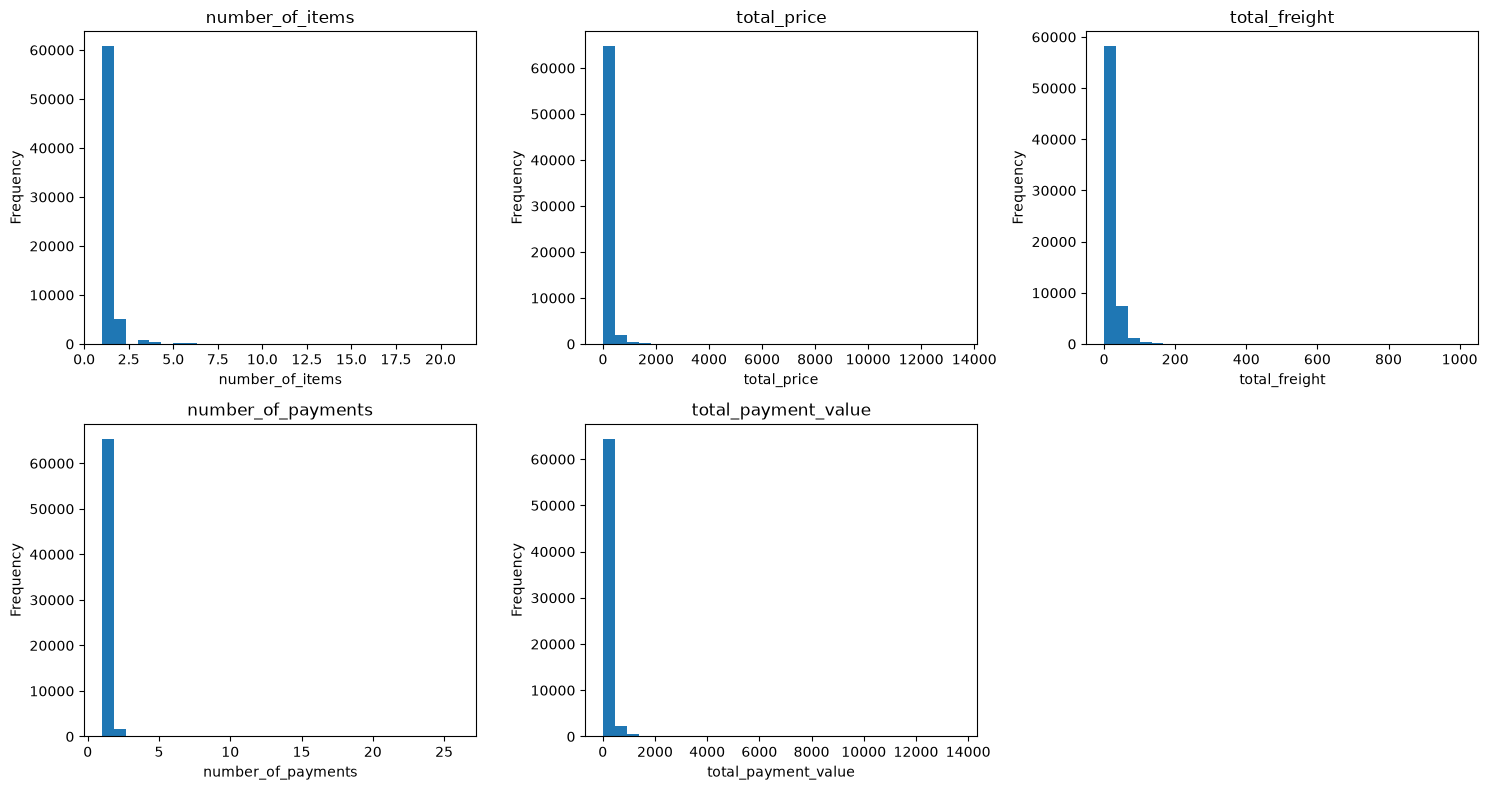

In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(train[col].dropna(), bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

# Hide the unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Numerical Features and Delivery Label

The relationship between numerical features and the delivery label was examined to identify variables that may provide predictive information about late deliveries.

In [70]:
train["late_flag"] = (
    train["delivery_label"] == "late"
).astype(int)

In [71]:
numeric_cols = [
    "number_of_items",
    "total_price",
    "total_freight",
    "number_of_payments",
    "total_payment_value"
]

train["late_flag"] = (
    train["delivery_label"] == "late"
).astype(int)

train[numeric_cols + ["late_flag"]].corr()["late_flag"].sort_values(
    ascending=False
)

late_flag              1.000000
total_freight          0.049654
total_payment_value    0.025528
total_price            0.021834
number_of_payments    -0.006094
number_of_items       -0.015031
Name: late_flag, dtype: float64

In [72]:
train.drop(columns="late_flag", inplace=True)

### Findings

The numerical features showed very weak linear correlations with the delivery label.

`total_freight` had the strongest positive correlation with late delivery (0.050), followed by `total_payment_value` (0.026) and `total_price` (0.022). `number_of_payments` and `number_of_items` showed correlations very close to zero.

Overall, no numerical feature showed a strong linear relationship with late delivery. However, weak correlation does not necessarily mean that a feature has no predictive value, since non-linear relationships and interactions may still be captured by the model.

## 6. Feature Redundancy

Pairwise correlations were examined to identify numerical variables that contain highly similar information.

In [73]:
train[
    [
        "number_of_items",
        "total_price",
        "total_freight",
        "number_of_payments",
        "total_payment_value"
    ]
].corr()

,number_of_items,total_price,total_freight,number_of_payments,total_payment_value
number_of_items,1.000000,0.155733,0.475176,-0.003912,0.193599
total_price,0.155733,1.000000,0.414521,0.000037,0.996354
total_freight,0.475176,0.414521,1.000000,0.000196,0.490457
number_of_payments,-0.003912,0.000037,0.000196,1.000000,0.000039
total_payment_value,0.193599,0.996354,0.490457,0.000039,1.000000


### Finding

`total_price` and `total_payment_value` showed an extremely strong correlation (r = 0.996), indicating that the two variables contain highly redundant information.

This redundancy will be considered during feature engineering, where one of the two variables may be removed to reduce unnecessary duplication.

## 7. Time-Based Analysis

Time-related variables were examined to identify patterns in late deliveries based on order timing and delivery windows.

Derived time features are created in this section for exploratory analysis and potential use during feature engineering.

In [74]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    train[col] = pd.to_datetime(train[col])

In [75]:
train["purchase_hour"] = train["order_purchase_timestamp"].dt.hour

train["purchase_hour"].describe()

count    67533.000000
mean        14.779486
std          5.353837
min          0.000000
25%         11.000000
50%         15.000000
75%         19.000000
max         23.000000
Name: purchase_hour, dtype: float64

In [76]:
hourly_late_rate = (
    train.groupby("purchase_hour")["delivery_label"]
    .apply(lambda x: (x == "late").mean() * 100)
)

hourly_late_rate

purchase_hour
0     8.664260
1     8.243728
2     7.027027
3     4.838710
4     5.882353
5     5.970149
6     6.918239
7     7.320099
8     7.483342
9     7.069449
10    7.642704
11    7.842697
12    8.053691
13    7.730673
14    7.773618
15    7.559055
16    7.628635
17    7.349081
18    7.583183
19    8.694581
20    8.192363
21    8.249881
22    8.078548
23    8.379121
Name: delivery_label, dtype: float64

### Purchase Hour Findings

Late-delivery rates showed only small variation across purchase hours. Most hourly rates were close to the overall late-delivery rate, ranging from approximately 4.8% to 8.7%.

This suggests that purchase hour does not show a strong direct relationship with delivery delays. However, it may still be retained as a candidate feature for model evaluation because non-linear effects may be captured by machine learning models.

In [77]:
train["purchase_weekday"] = train[
    "order_purchase_timestamp"
].dt.day_name()

weekday_late_rate = (
    train.groupby("purchase_weekday")["delivery_label"]
    .apply(lambda x: (x == "late").mean() * 100)
)

weekday_late_rate

purchase_weekday
Friday       8.174001
Monday       8.597243
Saturday     7.887806
Sunday       7.289266
Thursday     7.246377
Tuesday      7.987697
Wednesday    7.524906
Name: delivery_label, dtype: float64

### Purchase Weekday Findings

Late-delivery rates showed moderate variation across the days of the week.

Monday had the highest late-delivery rate (8.60%), followed by Friday (8.17%), while Thursday and Sunday had the lowest rates at approximately 7.25% and 7.29%.

The differences are relatively small, but purchase weekday may still provide useful time-related information and will be considered as a candidate feature during feature engineering.

In [80]:
train["order_purchase_timestamp"] = pd.to_datetime(
    train["order_purchase_timestamp"]
)

train["purchase_month"] = (
    train["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [81]:
monthly_late_rate = (
    train.groupby("purchase_month")["delivery_label"]
    .agg(
        orders="count",
        late_orders=lambda x: (x == "late").sum(),
        late_rate=lambda x: (x == "late").mean() * 100
    )
)

monthly_late_rate

,orders,late_orders,late_rate
purchase_month,,,
2016-09,1,1,100.000000
2016-10,270,2,0.740741
2016-12,1,0,0.000000
2017-01,750,22,2.933333
2017-02,1653,49,2.964307
2017-03,2546,116,4.556167
2017-04,2303,151,6.556665
2017-05,3545,106,2.990127
2017-06,3135,95,3.030303


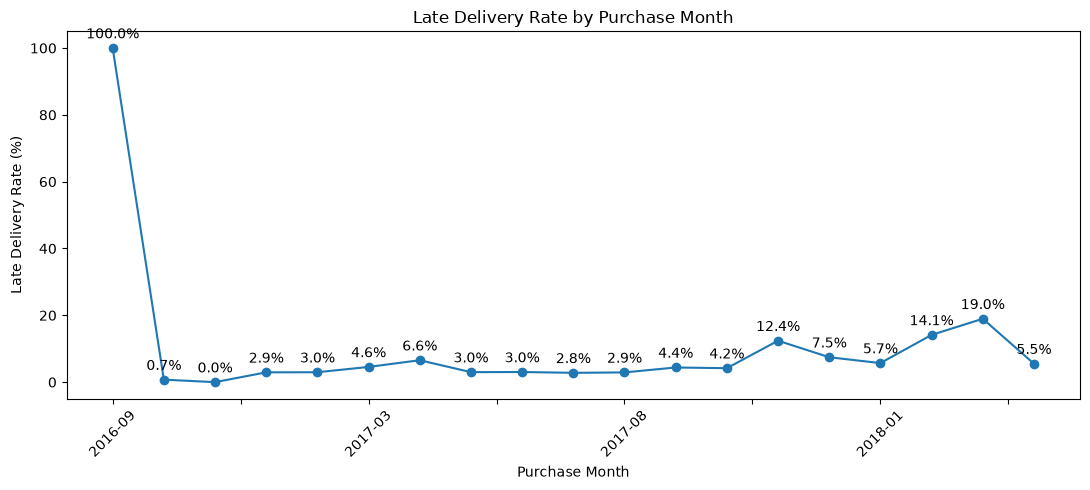

In [127]:
ax = monthly_late_rate["late_rate"].plot(
    kind="line",
    figsize=(11, 5),
    marker="o"
)

plt.title("Late Delivery Rate by Purchase Month")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)

for x, y in enumerate(monthly_late_rate["late_rate"]):
    ax.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    artifact_dir / "late_rate_by_purchase_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Purchase Month Findings

Late-delivery rates varied noticeably across purchase months, indicating a potential time-based or seasonal pattern.

The highest late-delivery rates among months with a substantial number of orders were observed in November 2017 (12.40%), February 2018 (14.14%), and March 2018 (18.96%). In contrast, several months during 2017 had late-delivery rates below 5%.

The extreme rates observed in September 2016 and December 2016 should be interpreted cautiously because each month contains only one order.

Overall, purchase month showed more variation in late-delivery rates than purchase hour or weekday and may be a useful candidate feature for feature engineering.


### Estimated and Actual Delivery Time

The estimated delivery window was examined to determine whether orders classified as late were originally assigned longer expected delivery times than on-time orders. The actual delivery duration was also analyzed to understand the observed difference in delivery behavior between the two classes.

`estimated_delivery_days` is calculated from information available when the order is placed and can therefore be considered as a potential model feature. In contrast, `actual_delivery_days` is only known after delivery and is used for exploratory analysis only to avoid data leakage.

In [82]:
train["estimated_delivery_days"] = (
    train["order_estimated_delivery_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / 86400

train["estimated_delivery_days"].describe()

count    67533.000000
mean        24.597288
std          8.022133
min          7.005127
25%         19.543333
50%         23.621377
75%         28.565984
max        155.135463
Name: estimated_delivery_days, dtype: float64

In [83]:
train.groupby("delivery_label")[
    "estimated_delivery_days"
].describe()

,count,mean,std,min,25%,50%,75%,max
delivery_label,,,,,,,,
late,5291.0,24.080616,6.388879,7.131644,20.151568,23.431875,27.555561,69.342373
on_time,62242.0,24.641209,8.144414,7.005127,19.515194,23.660856,28.638490,155.135463


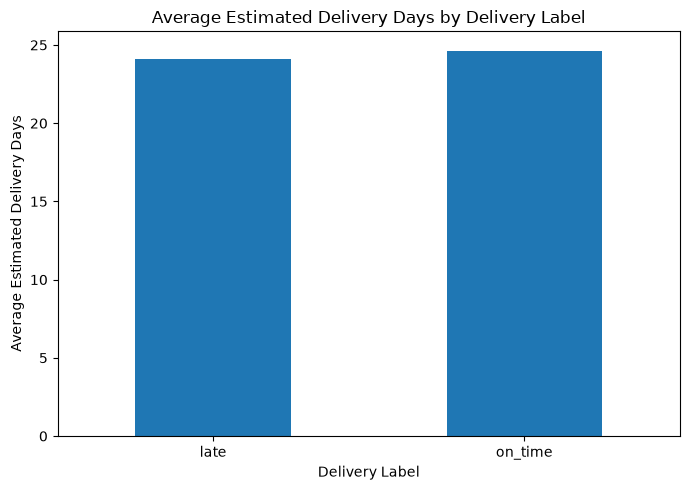

In [125]:
estimated_days_by_label = (
    train.groupby("delivery_label")["estimated_delivery_days"]
    .mean()
)

estimated_days_by_label.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Estimated Delivery Days by Delivery Label")
plt.xlabel("Delivery Label")
plt.ylabel("Average Estimated Delivery Days")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    artifact_dir / "estimated_delivery_days_by_label.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The estimated delivery window ranged from approximately 7 to 155 days, with a median of 23.62 days. Late and on-time orders had very similar estimated delivery windows, with average values of 24.08 days and 24.64 days, respectively.

This indicates that late orders were not generally assigned substantially longer estimated delivery windows than on-time orders. Therefore, `estimated_delivery_days` does not show a strong direct relationship with the delivery label, although it may still be evaluated as a candidate feature during modeling.


### Actual Delivery Duration

To better understand the difference in delivery behavior between late and on-time orders, the actual delivery duration was calculated as the time between the order purchase date and the actual customer delivery date.

This variable is used for exploratory analysis only because the actual delivery date is not available at the time a prediction would be made. Therefore, `actual_delivery_days` must not be used as a model feature to avoid data leakage.


In [84]:
train["actual_delivery_days"] = (
    train["order_delivered_customer_date"]
    - train["order_purchase_timestamp"]
).dt.total_seconds() / 86400

train["actual_delivery_days"].describe()

count    67533.000000
mean        13.824767
std         10.249351
min          0.533414
25%          7.450845
50%         11.475266
75%         17.189977
max        209.628611
Name: actual_delivery_days, dtype: float64

In [85]:
train.groupby("delivery_label")[
    "actual_delivery_days"
].describe()

,count,mean,std,min,25%,50%,75%,max
delivery_label,,,,,,,,
late,5291.0,36.222088,17.396866,8.215961,26.540503,33.061331,41.324566,209.628611
on_time,62242.0,11.920840,6.479793,0.533414,7.175943,10.891030,15.378044,70.213611


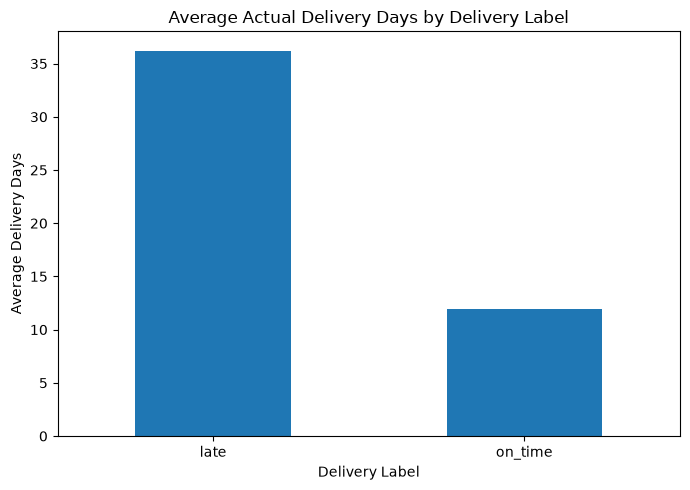

In [124]:
delivery_days_by_label = (
    train.groupby("delivery_label")["actual_delivery_days"]
    .mean()
)

delivery_days_by_label.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Actual Delivery Days by Delivery Label")
plt.xlabel("Delivery Label")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    artifact_dir / "actual_delivery_days_by_label.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding

Actual delivery duration differed substantially between the two delivery classes. Late orders had an average delivery duration of **36.22 days**, compared with **11.92 days** for on-time orders. The median duration was also considerably higher for late orders (**33.06 days**) than for on-time orders (**10.89 days**).

The distribution also contained extreme values, with a maximum actual delivery duration of approximately **209.63 days**.

This variable provides a clear description of the delivery outcome; however, `actual_delivery_days` will not be used as a model feature because it depends on the actual delivery date, which is only known after the delivery outcome. Including it in model training would introduce data leakage.


In [87]:
import holidays

br_holidays = holidays.Brazil(years=range(2016, 2019))

train["is_holiday"] = (
    train["order_purchase_timestamp"].dt.date.isin(br_holidays)
)

In [88]:
holiday_late_rate = (
    train.groupby("is_holiday")["delivery_label"]
    .agg(
        orders="count",
        late_orders=lambda x: (x == "late").sum(),
        late_rate=lambda x: (x == "late").mean() * 100
    )
)

holiday_late_rate

,orders,late_orders,late_rate
is_holiday,,,
False,66462,5234,7.875177
True,1071,57,5.322129


### Holiday Findings

Orders purchased on holidays had a lower late-delivery rate (5.32%) compared with orders purchased on non-holidays (7.88%).

However, holiday orders represent only 1,071 of the 67,533 training orders, so the difference should be interpreted cautiously. The result suggests that holiday status may contain some predictive information, but the observed relationship is not strong enough on its own to establish a clear effect.

Therefore, `is_holiday` can be considered as a candidate feature for feature engineering and evaluated further during modeling.


##  Geography Analysis

Geographical information was examined to determine whether the customer's and seller's locations are associated with late deliveries.

The current training table does not contain customer or seller location attributes. Therefore, the required geographical information will be retrieved from the original customer and seller tables using their corresponding IDs.

The analysis is performed on the training split only, and the geographical attributes are used for exploratory analysis and feature selection.


In [89]:
customers = pd.read_csv("../Data/raw/olist_customers_dataset.csv")


In [90]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [91]:
customers["customer_id"].isna().sum()

np.int64(0)

In [92]:
train = train.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

train["customer_state"].isna().sum()

np.int64(0)

In [ ]:
customer_state_late_rate = (
    train.groupby("customer_state")["delivery_label"]
    .agg(
        orders="count",
        late_orders=lambda x: (x == "late").sum(),
        late_rate=lambda x: (x == "late").mean() * 100
    )
    .sort_values("late_rate", ascending=False)
)

customer_state_late_rate

,orders,late_orders,late_rate
customer_state,,,
AL,298,74,24.832215
MA,548,107,19.525547
RR,29,5,17.241379
SE,246,42,17.073171
CE,948,158,16.666667
RJ,8967,1356,15.122114
PI,348,49,14.080460
BA,2307,301,13.047248
PB,370,45,12.162162


### Customer State Findings

Late-delivery rates varied considerably across customer states. The highest rates were observed in AL (24.83%), MA (19.53%), RR (17.24%), SE (17.07%), and CE (16.67%), while lower rates were observed in states such as SP (4.62%), PR (4.62%), and MG (5.25%).

However, the number of orders differs substantially between states. Some states with high late-delivery rates have relatively few observations, so their rates should be interpreted cautiously. Larger states, such as SP and RJ, provide more reliable estimates due to their much larger number of orders.

Overall, customer state shows meaningful variation in late-delivery rates and may provide useful geographical information for predicting delivery delays.

In [93]:
sellers = pd.read_csv("../Data/raw/olist_sellers_dataset.csv")

In [94]:
sellers["seller_id"].duplicated().sum()

np.int64(0)

In [95]:
sellers["seller_id"].isna().sum()

np.int64(0)

In [97]:
order_items = pd.read_csv("../Data/raw/olist_order_items_dataset.csv")
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [98]:
seller_count_per_order = (
    order_items.groupby("order_id")["seller_id"]
    .nunique()
)

seller_count_per_order.value_counts().sort_index()

seller_id
1    97388
2     1219
3       54
4        3
5        2
Name: count, dtype: int64

In [99]:
train["seller_count"] = (
    train["order_id"]
    .map(seller_count_per_order)
)

train.groupby("delivery_label")["seller_count"].describe()

,count,mean,std,min,25%,50%,75%,max
delivery_label,,,,,,,,
late,5291.0,1.002268,0.047574,1.0,1.0,1.0,1.0,2.0
on_time,62242.0,1.012885,0.118748,1.0,1.0,1.0,1.0,5.0


### Seller Count Findings

The number of sellers per order was highly concentrated around one seller. Both late and on-time orders had an average seller count close to 1, with medians of 1 for both groups.

This indicates that most orders were handled by a single seller, and the number of sellers does not show a meaningful difference between late and on-time orders. Therefore, `seller_count` is unlikely to provide substantial predictive value and will not be prioritized as a feature.


### Customer-Seller Distance

The geographical distance between the customer and seller locations was examined as a potential factor associated with delivery delays. Since the raw customer and seller tables provide ZIP-code prefixes rather than coordinates, the geolocation table is used to map ZIP-code prefixes to latitude and longitude coordinates.

The distance analysis is performed on the training split only.


In [100]:
geolocation = pd.read_csv("../Data/raw/olist_geolocation_dataset.csv")

geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [101]:
print("Rows:", len(geolocation))
print("Unique ZIP prefixes:", geolocation["geolocation_zip_code_prefix"].nunique())

Rows: 1000163
Unique ZIP prefixes: 19015


In [ ]:
geolocation.groupby("geolocation_zip_code_prefix").size().describe()

count    19015.000000
mean        52.598633
std         72.057907
min          1.000000
25%         10.000000
50%         29.000000
75%         66.500000
max       1146.000000
dtype: float64

In [102]:
geo_by_zip = (
    geolocation
    .groupby("geolocation_zip_code_prefix")
    .agg(
        latitude=("geolocation_lat", "mean"),
        longitude=("geolocation_lng", "mean")
    )
    .reset_index()
)

geo_by_zip.head()

,geolocation_zip_code_prefix,latitude,longitude
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [103]:
geo_by_zip["geolocation_zip_code_prefix"].duplicated().sum()

np.int64(0)

In [104]:
train = train.merge(
    customers[[
        "customer_id",
        "customer_zip_code_prefix"
    ]],
    on="customer_id",
    how="left"
)

train = train.merge(
    geo_by_zip,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

train[["customer_zip_code_prefix", "latitude", "longitude"]].isna().sum()

customer_zip_code_prefix      0
latitude                    181
longitude                   181
dtype: int64

In [105]:
train = train.rename(columns={
    "latitude": "customer_latitude",
    "longitude": "customer_longitude"
})

In [106]:
train[[
    "customer_zip_code_prefix",
    "customer_latitude",
    "customer_longitude"
]].head()

,customer_zip_code_prefix,customer_latitude,customer_longitude
0,14600,-20.585751,-47.863693
1,4106,-23.581451,-46.635029
2,98280,-28.293541,-53.502238
3,22770,-22.936911,-43.360973
4,90040,-30.041161,-51.213661


In [107]:
seller_per_order = (
    order_items
    .sort_values(["order_id", "order_item_id"])
    .drop_duplicates("order_id")
    [["order_id", "seller_id"]]
)

seller_per_order.head()

,order_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87


In [108]:
seller_geo = seller_per_order.merge(
    sellers[[
        "seller_id",
        "seller_zip_code_prefix"
    ]],
    on="seller_id",
    how="left"
)

seller_geo.head()

,order_id,seller_id,seller_zip_code_prefix
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,27277
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,3471
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,37564
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,14403
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,87900


In [109]:
seller_geo[[
    "seller_id",
    "seller_zip_code_prefix"
]].isna().sum()

seller_id                 0
seller_zip_code_prefix    0
dtype: int64

In [110]:
seller_geo = seller_geo.merge(
    geo_by_zip,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

seller_geo[["seller_zip_code_prefix", "latitude", "longitude"]].isna().sum()

seller_zip_code_prefix      0
latitude                  218
longitude                 218
dtype: int64

In [111]:
seller_geo = seller_geo.rename(columns={
    "latitude": "seller_latitude",
    "longitude": "seller_longitude"
})

In [ ]:
seller_geo = seller_geo[
    [
        "order_id",
        "seller_id",
        "seller_zip_code_prefix",
        "seller_latitude",
        "seller_longitude"
    ]
]
seller_geo.head()

,order_id,seller_id,seller_zip_code_prefix,seller_latitude,seller_longitude
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,27277,-22.496953,-44.127492
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,3471,-23.565096,-46.518565
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,37564,-22.262584,-46.171124
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,14403,-20.553624,-47.387359
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,87900,-22.929384,-53.135873


In [112]:
train = train.merge(
    seller_geo,
    on="order_id",
    how="left"
)

In [113]:
train[
    [
        "customer_latitude",
        "customer_longitude",
        "seller_latitude",
        "seller_longitude"
    ]
].isna().sum()

customer_latitude     181
customer_longitude    181
seller_latitude       165
seller_longitude      165
dtype: int64

In [114]:


def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

In [115]:
train["distance_km"] = haversine_distance(
    train["customer_latitude"],
    train["customer_longitude"],
    train["seller_latitude"],
    train["seller_longitude"]
)

In [116]:
train["distance_km"].describe()

count    67188.000000
mean       614.685730
std        594.990683
min          0.000000
25%        219.420601
50%        448.583670
75%        811.254211
max       5338.619521
Name: distance_km, dtype: float64

In [117]:
train["distance_group"] = pd.cut(
    train["distance_km"],
    bins=[0, 100, 250, 500, 1000, 2000, np.inf],
    labels=[
        "0-100 km",
        "100-250 km",
        "250-500 km",
        "500-1000 km",
        "1000-2000 km",
        "2000+ km"
    ],
    include_lowest=True
)

In [119]:
distance_late_rate = (
    train.groupby("distance_group", observed=True)["delivery_label"]
    .agg(
        orders="count",
        late_orders=lambda x: (x == "late").sum(),
        late_rate=lambda x: (x == "late").mean() * 100
    )
)

distance_late_rate

,orders,late_orders,late_rate
distance_group,,,
0-100 km,11620,440,3.786575
100-250 km,6401,334,5.217935
250-500 km,19525,1570,8.040973
500-1000 km,18611,1598,8.586320
1000-2000 km,7004,765,10.922330
2000+ km,4027,550,13.657810


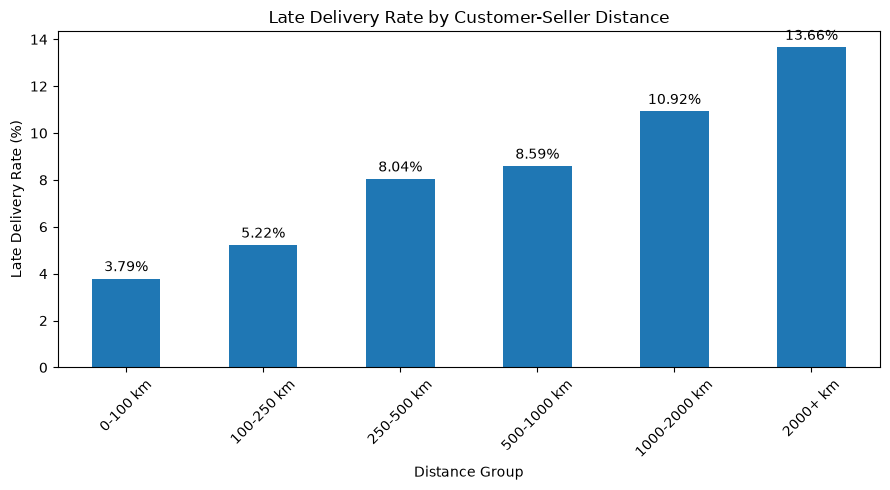

In [126]:
ax = distance_late_rate["late_rate"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Late Delivery Rate by Customer-Seller Distance")
plt.xlabel("Distance Group")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    artifact_dir / "late_rate_by_distance_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Customer-Seller Distance Findings

Delivery delays increased consistently as the geographical distance between the customer and seller increased. Orders within 0–100 km had the lowest late-delivery rate at 3.79%, while orders traveling more than 2,000 km had the highest rate at 13.66%.

The late-delivery rate more than tripled between the closest and farthest distance groups. This pattern suggests that longer shipping distances are strongly associated with a higher likelihood of delivery delays.

Overall, geographical distance appears to be one of the more meaningful factors identified in the EDA and is a strong candidate for feature engineering in the machine learning stage.


## Key EDA Findings

The exploratory data analysis identified several patterns associated with delivery delays.

### 1. Delivery Time

Actual delivery time showed a clear difference between late and on-time orders. Late orders had an average delivery time of approximately 36.22 days, compared with 11.92 days for on-time orders. This confirms a substantial difference in actual delivery duration between the two delivery classes.

### 2. Estimated Delivery Time

The estimated delivery time showed little difference between the two classes. Late orders had a mean estimated delivery time of 24.08 days, compared with 24.64 days for on-time orders. Therefore, estimated delivery time alone did not show a strong relationship with the delivery label.

### 3. Temporal Patterns

Late-delivery rates varied across purchase hours and weekdays, but the differences were relatively limited. Purchase month showed stronger variation, with particularly high late-delivery rates in November 2017, February 2018, and March 2018. Months with very few orders were interpreted cautiously.

### 4. Holidays

Holiday orders had a slightly lower late-delivery rate than non-holiday orders (5.32% vs. 7.88%). Therefore, the holiday indicator did not show a strong positive association with late deliveries in this dataset.

### 5. Customer Geography

Late-delivery rates varied considerably across customer states. Some states showed substantially higher rates than others; however, states with small numbers of orders were interpreted cautiously. Customer state may therefore provide useful geographical information.

### 6. Seller Information

Most orders were associated with a single seller, and the number of sellers per order showed little difference between late and on-time orders. Therefore, `seller_count` is unlikely to be a strong predictive feature.

### 7. Customer-Seller Distance

Geographical distance showed one of the clearest patterns in the analysis. The late-delivery rate increased from 3.79% for orders traveling less than 100 km to 13.66% for orders traveling more than 2,000 km. This suggests that longer shipping distances are strongly associated with delivery delays.

### 8. Correlation Analysis

The numerical correlation analysis showed generally weak linear correlations with the delivery label. `total_freight` had the strongest positive correlation (0.050), followed by `total_payment_value` (0.026) and `total_price` (0.022). These correlations are weak, indicating that linear correlation alone does not capture the relationships between the features and delivery delays.

### Overall Conclusion

The EDA suggests that delivery delays are influenced more by operational and geographical factors than by order value or purchase timing alone. In particular, actual delivery duration and customer-seller distance showed clear differences between delivery classes. Temporal and geographical variables may also provide useful information for the machine learning model, while highly correlated or weakly informative variables should be evaluated carefully during feature engineering.


## Next Step

Based on the EDA findings, the next stage is to perform feature engineering and prepare the dataset for machine learning. Features will be selected and transformed while maintaining the one-row-per-order structure and avoiding data leakage.
